# Agentic AI Orchestration for Collaborative Split Inference in Wireless Networks

### Idea

We use a pretrained AI model split between a device and a server.
Intermediate features are sent through a simulated wireless channel,
and an agent selects the split point and compression level based on
the current network condition.

We test two agents:
- Contextual bandit with epsilon-greedy exploration
- LinUCB using SNR as the context

We also check privacy leakage using a reconstruction attack.

### Sections

1. Setup
2. Data + Pretrained Model
3. Model Splitting
4. Wireless Channel Simulator
5. Privacy Leakage Probe (Reconstruction Attack)
6. Agent (Contextual Bandit)
7. Baselines
8. Main Experiment Loop
9. Results and Visualization
11. Agent Decisions Over Time
12. Final Comparison Table
13. Final Agent Training and Evaluation
14. LinUCB Agent for Adaptive Inference
15. LinUCB Learned Policy

## 1. Setup

In [9]:
# 1. Setup
!pip install -q torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import os

seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", dev)

out_dir = "/content/results"
os.makedirs(out_dir, exist_ok=True)


using device: cuda


#2. Data + Pretrained Model



In [10]:
# CIFAR-10 is a small real-world benchmark dataset that is

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

test_set = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_tf
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

classes = test_set.classes

print("number of test images:", len(test_set))
print("classes:", classes)

# Load a pretrained CIFAR-10 ResNet-20 model
base_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models",
    "cifar10_resnet20",
    pretrained=True
)

base_model = base_model.to(dev)
base_model.eval()

print("model loaded successfully")

100%|██████████| 170M/170M [56:19<00:00, 50.5kB/s]


number of test images: 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
The repository chenyaofo_pytorch-cifar-models does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 28.6MB/s]


model loaded successfully


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
import os

drive_data = "/content/drive/MyDrive/cifar10"
os.makedirs(drive_data, exist_ok=True)

print(drive_data)

/content/drive/MyDrive/cifar10


In [12]:
# Quick baseline accuracy

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(dev)
        labels = labels.to(dev)

        outputs = base_model(imgs)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

baseline_acc = 100 * correct / total

print(f"baseline accuracy: {baseline_acc:.2f}%")

baseline accuracy: 92.12%


# 3. Splitting the model

In [13]:
# 3. Model Splitting
# We divide the model into a device part and a server part.
# The cut decides how many layers run on the device.

def device_forward(x, cut):
    m = base_model

    x = m.relu(m.bn1(m.conv1(x)))

    if cut >= 1:
        x = m.layer1(x)
    if cut >= 2:
        x = m.layer2(x)
    if cut >= 3:
        x = m.layer3(x)

    return x


def server_forward(feat, cut):
    m = base_model
    x = feat

    if cut < 1:
        x = m.layer1(x)
    if cut < 2:
        x = m.layer2(x)
    if cut < 3:
        x = m.layer3(x)

    x = m.avgpool(x)
    x = torch.flatten(x, 1)
    x = m.fc(x)

    return x

In [14]:
# Check that splitting the model gives the same output as the full model.

with torch.no_grad():
    imgs, labels = next(iter(test_loader))
    imgs = imgs.to(dev)

    full_output = base_model(imgs)

    for cut in [0, 1, 2, 3]:
        split_output = server_forward(device_forward(imgs, cut), cut)
        max_diff = (full_output - split_output).abs().max().item()

        print(f"cut = {cut}, max difference = {max_diff:.8f}")

cut = 0, max difference = 0.00000000
cut = 1, max difference = 0.00000000
cut = 2, max difference = 0.00000000
cut = 3, max difference = 0.00000000


#4. Wireless Channel Simulator

In [15]:
# The channel changes over time, so the SNR also changes.
# Lower SNR means more noise in the transmitted features.
# We also use fewer bits to reduce the amount of data sent.

def quantize(feat, bits):
    if bits >= 32:
        return feat

    fmin = feat.min()
    fmax = feat.max()

    if fmax == fmin:
        return feat

    levels = 2 ** bits
    scaled = (feat - fmin) / (fmax - fmin)
    q = torch.round(scaled * (levels - 1)) / (levels - 1)

    return q * (fmax - fmin) + fmin


def add_channel_noise(feat, snr_db):
    signal_power = feat.pow(2).mean()
    snr_linear = 10 ** (snr_db / 10.0)
    noise_power = signal_power / snr_linear

    noise = torch.randn_like(feat) * torch.sqrt(noise_power)

    return feat + noise


class ChannelSim:
    def __init__(self, snr_lo=0, snr_hi=25, start=15, step=3):
        self.snr_lo = snr_lo
        self.snr_hi = snr_hi
        self.step = step
        self.snr = start

    def tick(self):
        self.snr += random.uniform(-self.step, self.step)
        self.snr = max(self.snr_lo, min(self.snr, self.snr_hi))

        return self.snr

    def send(self, feat, bits):
        quantized = quantize(feat, bits)
        noisy = add_channel_noise(quantized, self.snr)

        # Estimate transmitted data size in bytes
        bytes_sent = feat.numel() * bits / 8.0

        return noisy, bytes_sent

## 5. Privacy Leakage Probe


In [16]:
# We test how well an image can be reconstructed from the transmitted features.
# Lower reconstruction error means more information about the image is retained.

class TinyDecoder(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_ch, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Upsample(size=(32, 32), mode="bilinear", align_corners=False)
        )

    def forward(self, x):
        return self.net(x)


def train_decoder_for_cut(cut, epochs=2):
    # Get the feature size for this cut
    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(dev)

    with torch.no_grad():
        feat = device_forward(imgs, cut)

    in_ch = feat.shape[1]

    decoder = TinyDecoder(in_ch).to(dev)
    optimizer = torch.optim.Adam(decoder.parameters(), lr=1e-3)

    train_set = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=test_tf
    )

    train_loader = torch.utils.data.DataLoader(
        train_set,
        batch_size=128,
        shuffle=True,
        num_workers=2
    )

    decoder.train()

    for epoch in range(epochs):
        total_loss = 0.0
        batches = 0

        for imgs, _ in train_loader:
            imgs = imgs.to(dev)

            with torch.no_grad():
                feat = device_forward(imgs, cut)

            recon = decoder(feat)
            loss = F.mse_loss(recon, imgs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            batches += 1

        print(
            f"cut {cut}, epoch {epoch + 1}, "
            f"reconstruction loss: {total_loss / batches:.6f}"
        )

    return decoder


# Train and evaluate a decoder for each cut
leak_table = {}
decoders = {}

for cut in [0, 1, 2, 3]:
    decoder = train_decoder_for_cut(cut, epochs=2)
    decoders[cut] = decoder

    imgs, _ = next(iter(test_loader))
    imgs = imgs.to(dev)

    with torch.no_grad():
        feat = device_forward(imgs, cut)
        recon = decoder(feat)
        error = F.mse_loss(recon, imgs).item()

    leak_table[cut] = error

    print(f"cut {cut}, test reconstruction MSE: {error:.6f}")


# Convert reconstruction error into a relative leakage score.
# Higher score means more reconstruction information is retained.
max_error = max(leak_table.values())
min_error = min(leak_table.values())

leakage_score = {}

for cut in leak_table:
    leakage_score[cut] = (
        1.0 - (leak_table[cut] - min_error)
        / (max_error - min_error + 1e-8)
    )

print("\nLeakage scores:")
for cut, score in leakage_score.items():
    print(f"cut {cut}: {score:.4f}")

cut 0, epoch 1, reconstruction loss: 0.101530
cut 0, epoch 2, reconstruction loss: 0.005627
cut 0, test reconstruction MSE: 0.004469
cut 1, epoch 1, reconstruction loss: 0.193026
cut 1, epoch 2, reconstruction loss: 0.085038
cut 1, test reconstruction MSE: 0.075509
cut 2, epoch 1, reconstruction loss: 0.320418
cut 2, epoch 2, reconstruction loss: 0.197299
cut 2, test reconstruction MSE: 0.180746
cut 3, epoch 1, reconstruction loss: 0.784219
cut 3, epoch 2, reconstruction loss: 0.677812
cut 3, test reconstruction MSE: 0.646122

Leakage scores:
cut 0: 1.0000
cut 1: 0.8893
cut 2: 0.7253
cut 3: 0.0000


## 6. Contextual Bandit Agent


In [17]:
# 6. Contextual Bandit Agent
# The agent observes the current SNR and chooses a cut and bit level.
# For this experiment, we first optimize accuracy only.

cut_choices = [0, 1, 2, 3]
bit_choices = [2, 4, 8, 32]

actions = [
    (cut, bits)
    for cut in cut_choices
    for bits in bit_choices
]


def snr_to_bucket(snr, n_buckets=5, lo=0, hi=25):
    span = (hi - lo) / n_buckets
    bucket = int((snr - lo) // span)

    return max(0, min(n_buckets - 1, bucket))

n_buckets = 5

class BanditAgent:
    def __init__(
        self,
        actions,
        n_states,
        lr=0.2,
        eps=0.4,
        eps_min=0.02,
        eps_decay=0.998
    ):
        self.actions = actions
        self.lr = lr

        # Start with more exploration
        self.eps = eps
        self.eps_min = eps_min
        self.eps_decay = eps_decay

        self.q = np.zeros(
            (n_states, len(actions))
        )

    def choose(self, state, training=True):

        # During training: explore + exploit
        if training and random.random() < self.eps:
            action_idx = random.randrange(
                len(self.actions)
            )

        # During evaluation: choose the learned best action
        else:
            action_idx = int(
                np.argmax(self.q[state])
            )

        return action_idx, self.actions[action_idx]

    def update(
        self,
        state,
        action_idx,
        reward
    ):
        old_value = self.q[
            state,
            action_idx
        ]

        self.q[
            state,
            action_idx
        ] = (
            old_value
            + self.lr
            * (reward - old_value)
        )

        # Gradually reduce exploration
        self.eps = max(
            self.eps_min,
            self.eps * self.eps_decay
        )


agent = BanditAgent(
    actions,
    n_buckets
)


# Reward weights
# First experiment: accuracy only
w_acc = 1.0
w_bytes = 0.00005
w_leak = 0.10

print("Agent initialized.")
print("Number of states:", n_buckets)
print("Number of actions:", len(actions))
print("Initial epsilon:", agent.eps)

Agent initialized.
Number of states: 5
Number of actions: 16
Initial epsilon: 0.4


# 7. Baselines


In [18]:
# We compare the agent with three simple fixed strategies.

baseline_policies = {
    "always_cloud": (0, 8),
    "always_edge": (3, 8),
    "fixed_split": (2, 8),
}


def run_one_step(imgs, lbls, cut, bits, channel):
    # Run the device part
    feat = device_forward(imgs, cut)

    # Send features through the simulated channel
    noisy_feat, bytes_sent = channel.send(feat, bits)

    # Run the server part
    with torch.no_grad():
        logits = server_forward(noisy_feat, cut)

    predictions = logits.argmax(dim=1)
    correct = (predictions == lbls).sum().item()

    return correct, bytes_sent

# 8. Main Experiment


In [19]:
random.seed(123)
np.random.seed(123)
torch.manual_seed(123)

n_train = 3000
n_eval = 250

results = {
    name: {"acc": [], "bytes": [], "snr": []}
    for name in list(baseline_policies.keys()) + ["agentic"]
}


data_iter = iter(test_loader)


def get_batch():
    global data_iter

    try:
        return next(data_iter)
    except StopIteration:
        data_iter = iter(test_loader)
        return next(data_iter)


# Train the agent
train_channel = ChannelSim(
    snr_lo=0,
    snr_hi=25,
    start=15,
    step=3
)

print("Starting training...")

for episode in range(n_train):

    imgs, labels = get_batch()

    imgs = imgs.to(dev)
    labels = labels.to(dev)

    snr_now = train_channel.tick()
    state = snr_to_bucket(snr_now, n_buckets)

    action_idx, (cut, bits) = agent.choose(
        state,
        training=True
    )

    correct, bytes_sent = run_one_step(
        imgs,
        labels,
        cut,
        bits,
        train_channel
    )

    accuracy = correct / imgs.shape[0]

    reward = (
        w_acc * accuracy
        - w_bytes * bytes_sent / 1000.0
        - w_leak * leakage_score[cut]
    )

    agent.update(
        state,
        action_idx,
        reward
    )

    if episode % 500 == 0:
        print(
            f"episode {episode}, "
            f"SNR {snr_now:.1f}, "
            f"cut={cut}, "
            f"bits={bits}, "
            f"accuracy={accuracy:.3f}, "
            f"epsilon={agent.eps:.3f}"
        )

print("Training finished.")
print(f"Final epsilon: {agent.eps:.3f}")


# Evaluate the learned policy
print("\nStarting evaluation...")

eval_channel = ChannelSim(
    snr_lo=0,
    snr_hi=25,
    start=15,
    step=3
)

data_iter = iter(test_loader)


for episode in range(n_eval):

    imgs, labels = get_batch()

    imgs = imgs.to(dev)
    labels = labels.to(dev)

    snr_now = eval_channel.tick()
    state = snr_to_bucket(snr_now, n_buckets)

    # Fixed baselines
    for name, (cut, bits) in baseline_policies.items():

        correct, bytes_sent = run_one_step(
            imgs,
            labels,
            cut,
            bits,
            eval_channel
        )

        results[name]["acc"].append(
            correct / imgs.shape[0]
        )

        results[name]["bytes"].append(
            bytes_sent
        )

        results[name]["snr"].append(
            snr_now
        )


    # Agent
    action_idx, (cut, bits) = agent.choose(
        state,
        training=False
    )

    correct, bytes_sent = run_one_step(
        imgs,
        labels,
        cut,
        bits,
        eval_channel
    )

    results["agentic"]["acc"].append(
        correct / imgs.shape[0]
    )

    results["agentic"]["bytes"].append(
        bytes_sent
    )

    results["agentic"]["snr"].append(
        snr_now
    )

    if episode % 50 == 0:
        print(
            f"episode {episode}, "
            f"SNR {snr_now:.1f}, "
            f"agent choice: cut={cut}, "
            f"bits={bits}, "
            f"accuracy={correct / imgs.shape[0]:.3f}"
        )

print("Evaluation finished.")

Starting training...
episode 0, SNR 12.3, cut=3, bits=4, accuracy=0.906, epsilon=0.399
episode 500, SNR 3.5, cut=3, bits=32, accuracy=0.906, epsilon=0.147
episode 1000, SNR 11.2, cut=3, bits=4, accuracy=0.969, epsilon=0.054
episode 1500, SNR 14.8, cut=3, bits=4, accuracy=0.953, epsilon=0.020
episode 2000, SNR 19.1, cut=0, bits=4, accuracy=0.906, epsilon=0.020
episode 2500, SNR 8.9, cut=3, bits=4, accuracy=0.953, epsilon=0.020
Training finished.
Final epsilon: 0.020

Starting evaluation...
episode 0, SNR 12.8, agent choice: cut=3, bits=4, accuracy=0.906
episode 50, SNR 15.4, agent choice: cut=0, bits=4, accuracy=0.859
episode 100, SNR 21.0, agent choice: cut=0, bits=2, accuracy=0.750
episode 150, SNR 0.0, agent choice: cut=3, bits=32, accuracy=0.953
episode 200, SNR 16.0, agent choice: cut=0, bits=4, accuracy=0.906
Evaluation finished.


# 9A. Results: Accuracy and Communication Cost


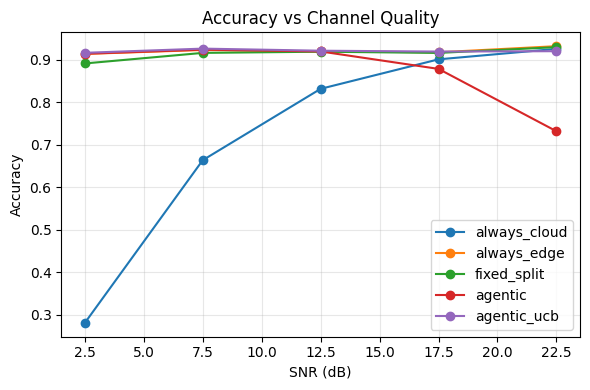

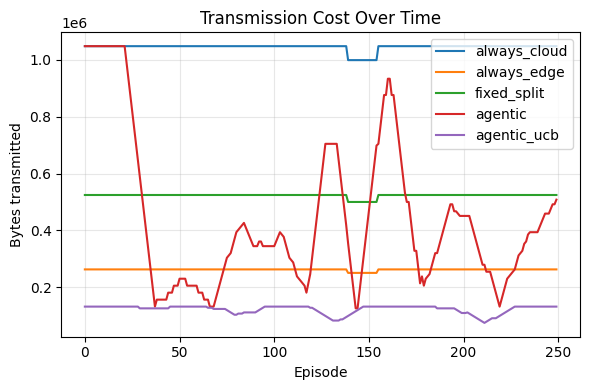


Summary Table
Method         Avg Accuracy   Avg Bytes      
always_cloud   0.718          1045430.3      
always_edge    0.920          261357.6       
fixed_split    0.914          522715.1       
agentic        0.889          424804.4       
agentic_ucb    0.921          121634.8       


In [33]:
def bin_and_avg(snr_list, val_list, n_buckets=5, lo=0, hi=25):
    buckets = [[] for _ in range(n_buckets)]

    for snr, value in zip(snr_list, val_list):
        bucket = snr_to_bucket(snr, n_buckets, lo, hi)
        buckets[bucket].append(value)

    return [
        np.mean(bucket) if bucket else np.nan
        for bucket in buckets
    ]


bucket_centers = [(i + 0.5) * 5 for i in range(5)]


# Accuracy vs SNR
plt.figure(figsize=(6, 4))

for name in results:
    avg_accuracy = bin_and_avg(
        results[name]["snr"],
        results[name]["acc"]
    )
    plt.plot(
        bucket_centers,
        avg_accuracy,
        marker="o",
        label=name
    )

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Channel Quality")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(out_dir, "fig1_accuracy_vs_snr.png"),
    dpi=200
)

plt.show()


# Communication cost over time
plt.figure(figsize=(6, 4))

window = 15

for name in results:
    bytes_sent = results[name]["bytes"]

    smoothed = [
        np.mean(bytes_sent[max(0, i-window):i+1])
        for i in range(len(bytes_sent))
    ]

    plt.plot(smoothed, label=name)

plt.xlabel("Episode")
plt.ylabel("Bytes transmitted")
plt.title("Transmission Cost Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    os.path.join(out_dir, "fig2_bytes_over_time.png"),
    dpi=200
)

plt.show()


# Summary table
print("\nSummary Table")
print(f"{'Method':<15}{'Avg Accuracy':<15}{'Avg Bytes':<15}")

for name in results:
    avg_acc = np.mean(results[name]["acc"])
    avg_bytes = np.mean(results[name]["bytes"])

    print(
        f"{name:<15}"
        f"{avg_acc:<15.3f}"
        f"{avg_bytes:<15.1f}"
    )

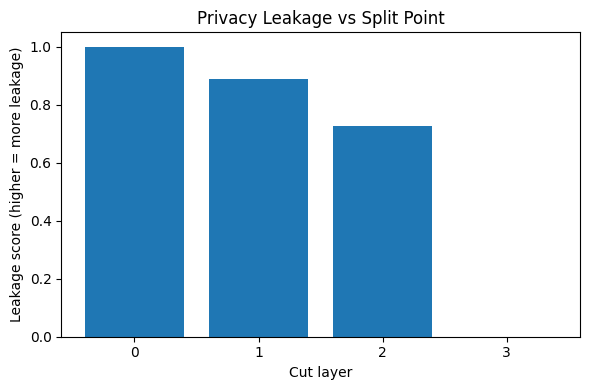

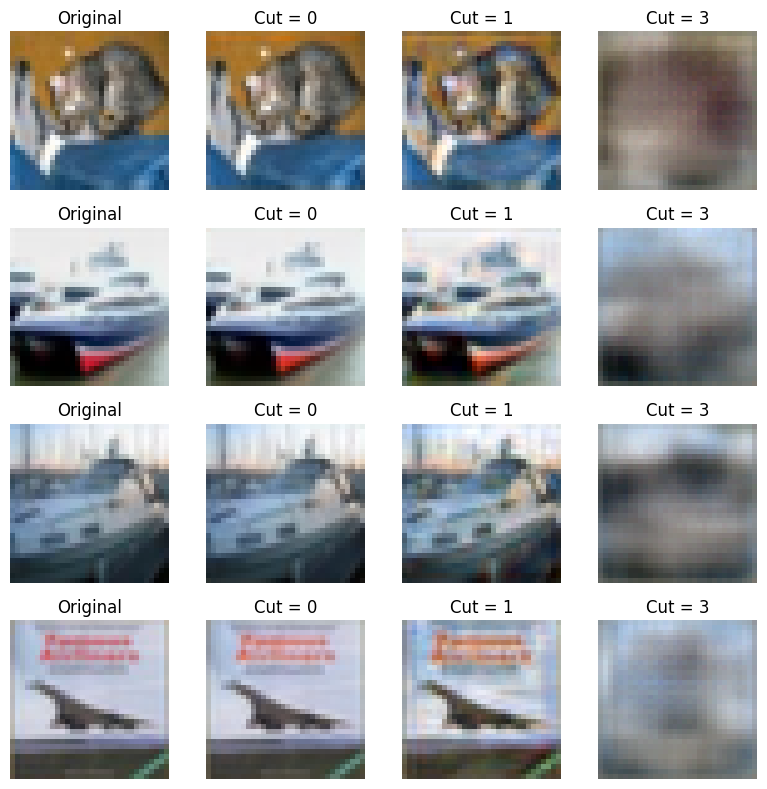

In [34]:
# 9B. Privacy Results and Sample Reconstructions

# Privacy leakage vs split point
plt.figure(figsize=(6, 4))

cuts = sorted(leakage_score.keys())
scores = [leakage_score[c] for c in cuts]

plt.bar(
    [str(c) for c in cuts],
    scores
)

plt.xlabel("Cut layer")
plt.ylabel("Leakage score (higher = more leakage)")
plt.title("Privacy Leakage vs Split Point")
plt.tight_layout()

plt.savefig(
    os.path.join(out_dir, "fig3_privacy_vs_cut.png"),
    dpi=200
)

plt.show()


# Sample image reconstructions
imgs, _ = next(iter(test_loader))
imgs = imgs[:4].to(dev)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))

un_mean = torch.tensor(mean).view(3, 1, 1)
un_std = torch.tensor(std).view(3, 1, 1)


def unnorm(image):
    image = image.cpu() * un_std + un_mean
    return image.clamp(0, 1).permute(1, 2, 0).numpy()


for row in range(4):

    axes[row][0].imshow(unnorm(imgs[row]))
    axes[row][0].set_title("Original")
    axes[row][0].axis("off")

    for col, cut in enumerate([0, 1, 3]):

        with torch.no_grad():
            feat = device_forward(
                imgs[row:row+1],
                cut
            )
            recon = decoders[cut](feat)[0]

        axes[row][col + 1].imshow(unnorm(recon))
        axes[row][col + 1].set_title(f"Cut = {cut}")
        axes[row][col + 1].axis("off")


plt.tight_layout()

plt.savefig(
    os.path.join(out_dir, "fig4_reconstructions.png"),
    dpi=200
)

plt.show()

# 11. Agent's Learned Policy


SNR 0-5 dB: cut=3, bits=32
SNR 5-10 dB: cut=3, bits=4
SNR 10-15 dB: cut=3, bits=4
SNR 15-20 dB: cut=0, bits=4
SNR 20-25 dB: cut=0, bits=2


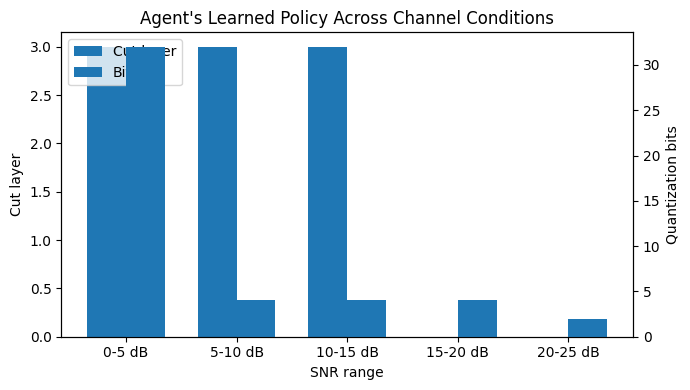

In [35]:
# Show which cut and bit level the agent learned for each SNR range.

learned_cut = []
learned_bits = []

for state in range(n_buckets):
    best_idx = int(np.argmax(agent.q[state]))
    cut, bits = agent.actions[best_idx]

    learned_cut.append(cut)
    learned_bits.append(bits)

    lo = state * (25 / n_buckets)
    hi = (state + 1) * (25 / n_buckets)

    print(
        f"SNR {lo:.0f}-{hi:.0f} dB: "
        f"cut={cut}, bits={bits}"
    )


# Plot the learned policy
fig, ax1 = plt.subplots(figsize=(7, 4))

x = np.arange(n_buckets)
width = 0.35

ax1.bar(
    x - width / 2,
    learned_cut,
    width,
    label="Cut layer"
)

ax1.set_xlabel("SNR range")
ax1.set_ylabel("Cut layer")
ax1.set_xticks(x)
ax1.set_xticklabels([
    f"{int(i * 5)}-{int((i + 1) * 5)} dB"
    for i in range(n_buckets)
])

ax2 = ax1.twinx()

ax2.bar(
    x + width / 2,
    learned_bits,
    width,
    label="Bits"
)

ax2.set_ylabel("Quantization bits")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Agent's Learned Policy Across Channel Conditions")
plt.tight_layout()

plt.savefig(
    os.path.join(out_dir, "fig5_agent_policy.png"),
    dpi=200
)

plt.show()

# 11B. Agent Decisions Over Time


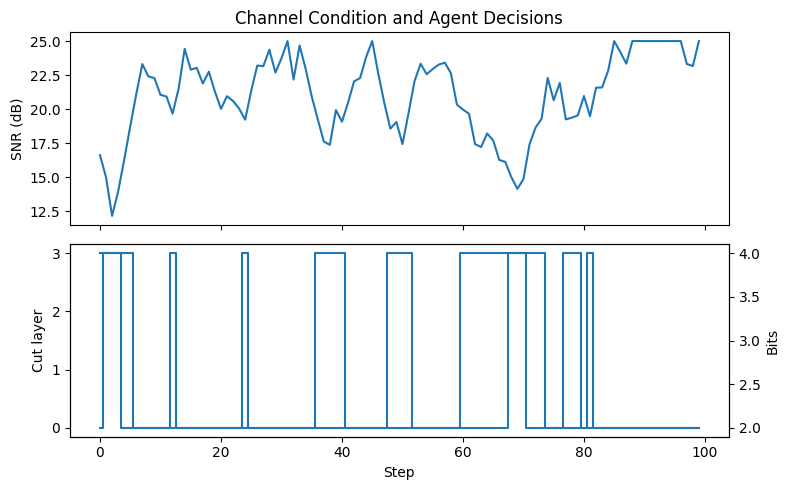

In [36]:
# Freeze exploration and show how the learned policy responds
# to changing channel conditions.

agent.eps = 0.0

trace_snr = []
trace_cut = []
trace_bits = []

trace_channel = ChannelSim(
    snr_lo=0,
    snr_hi=25,
    start=15,
    step=3
)

for step in range(100):
    snr_now = trace_channel.tick()

    state = snr_to_bucket(snr_now, n_buckets)
    _, (cut, bits) = agent.choose(state)

    trace_snr.append(snr_now)
    trace_cut.append(cut)
    trace_bits.append(bits)


fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 5),
    sharex=True
)

# Channel condition
axes[0].plot(trace_snr)

axes[0].set_ylabel("SNR (dB)")
axes[0].set_title("Channel Condition and Agent Decisions")


# Agent decisions
axes[1].step(
    range(len(trace_cut)),
    trace_cut,
    where="mid",
    label="Cut layer"
)

ax_bits = axes[1].twinx()

ax_bits.step(
    range(len(trace_bits)),
    trace_bits,
    where="mid",
    label="Bits"
)

axes[1].set_ylabel("Cut layer")
ax_bits.set_ylabel("Bits")
axes[1].set_xlabel("Step")

plt.tight_layout()

plt.savefig(
    os.path.join(out_dir, "fig6_agent_decisions_over_time.png"),
    dpi=200
)

plt.show()

In [25]:
# 10. Package all report files

import shutil

shutil.make_archive(
    "/content/report_files",
    "zip",
    out_dir
)

print("All report files saved to /content/report_files.zip")

All report files saved to /content/report_files.zip


In [30]:
# 13. Final Agent Training and Evaluation

w_acc = 1.0
w_bytes = 0.00005
w_leak = 0.10

print(
    f"weights: accuracy={w_acc}, "
    f"bytes={w_bytes}, leakage={w_leak}"
)

random.seed(123)
np.random.seed(123)
torch.manual_seed(123)

agent = BanditAgent(
    actions,
    n_buckets,
    lr=0.2,
    eps=0.4,
    eps_min=0.02,
    eps_decay=0.998
)

train_steps = 3000
test_steps = 250

results = {
    name: {"acc": [], "bytes": [], "snr": []}
    for name in list(baseline_policies.keys()) + ["agentic"]
}

channel = ChannelSim(
    snr_lo=0,
    snr_hi=25,
    start=15,
    step=3
)

data_iter = iter(test_loader)

def get_batch():
    global data_iter

    try:
        return next(data_iter)
    except StopIteration:
        data_iter = iter(test_loader)
        return next(data_iter)


print("Starting training...")

for step in range(train_steps):

    imgs, labels = get_batch()
    imgs = imgs.to(dev)
    labels = labels.to(dev)

    snr = channel.tick()
    state = snr_to_bucket(snr, n_buckets)

    action_idx, (cut, bits) = agent.choose(
        state,
        training=True
    )

    correct, bytes_sent = run_one_step(
        imgs,
        labels,
        cut,
        bits,
        channel
    )

    accuracy = correct / imgs.shape[0]

    reward = (
        w_acc * accuracy
        - w_bytes * bytes_sent / 1000.0
        - w_leak * leakage_score[cut]
    )

    agent.update(
        state,
        action_idx,
        reward
    )

    if step % 500 == 0:
        print(
            f"step {step}, "
            f"SNR={snr:.1f}, "
            f"cut={cut}, "
            f"bits={bits}, "
            f"accuracy={accuracy:.3f}, "
            f"reward={reward:.4f}, "
            f"epsilon={agent.eps:.3f}"
        )

print("Training finished.")
print(f"Final epsilon: {agent.eps:.3f}")


print("\nStarting evaluation...")

for step in range(test_steps):

    imgs, labels = get_batch()
    imgs = imgs.to(dev)
    labels = labels.to(dev)

    snr = channel.tick()

    for name, (cut, bits) in baseline_policies.items():

        correct, bytes_sent = run_one_step(
            imgs,
            labels,
            cut,
            bits,
            channel
        )

        results[name]["acc"].append(
            correct / imgs.shape[0]
        )

        results[name]["bytes"].append(
            bytes_sent
        )

        results[name]["snr"].append(
            snr
        )

    state = snr_to_bucket(snr, n_buckets)

    _, (cut, bits) = agent.choose(
        state,
        training=False
    )

    correct, bytes_sent = run_one_step(
        imgs,
        labels,
        cut,
        bits,
        channel
    )

    results["agentic"]["acc"].append(
        correct / imgs.shape[0]
    )

    results["agentic"]["bytes"].append(
        bytes_sent
    )

    results["agentic"]["snr"].append(
        snr
    )

print("Evaluation finished.")

print("\nSummary Table")
print(f"{'Method':<15}{'Avg Accuracy':<15}{'Avg Bytes':<15}")

for name in results:

    avg_acc = np.mean(results[name]["acc"])
    avg_bytes = np.mean(results[name]["bytes"])

    print(
        f"{name:<15}"
        f"{avg_acc:<15.3f}"
        f"{avg_bytes:<15.1f}"
    )

weights: accuracy=1.0, bytes=5e-05, leakage=0.1
Starting training...
step 0, SNR=12.3, cut=3, bits=4, accuracy=0.906, reward=0.8997, epsilon=0.399
step 500, SNR=3.5, cut=3, bits=32, accuracy=0.906, reward=0.8538, epsilon=0.147
step 1000, SNR=11.2, cut=3, bits=4, accuracy=0.969, reward=0.9622, epsilon=0.054
step 1500, SNR=14.8, cut=3, bits=4, accuracy=0.953, reward=0.9466, epsilon=0.020
step 2000, SNR=19.1, cut=0, bits=4, accuracy=0.906, reward=0.7800, epsilon=0.020
step 2500, SNR=8.9, cut=3, bits=4, accuracy=0.953, reward=0.9466, epsilon=0.020
Training finished.
Final epsilon: 0.020

Starting evaluation...
Evaluation finished.

Summary Table
Method         Avg Accuracy   Avg Bytes      
always_cloud   0.718          1045430.3      
always_edge    0.920          261357.6       
fixed_split    0.914          522715.1       
agentic        0.889          424804.4       


In [31]:
# 14. LinUCB Agent for Adaptive Inference

class LinUCBAgent:
    def __init__(self, actions, context_dim=2, alpha=1.0):
        self.actions = actions
        self.alpha = alpha

        self.A = [
            np.eye(context_dim)
            for _ in actions
        ]

        self.b = [
            np.zeros(context_dim)
            for _ in actions
        ]

    def get_context(self, snr):
        return np.array([
            snr / 25.0,
            1.0
        ])

    def choose(self, snr, training=True):
        x = self.get_context(snr)
        scores = []

        for i in range(len(self.actions)):
            A_inv = np.linalg.inv(self.A[i])
            theta = A_inv @ self.b[i]

            mean = theta @ x
            uncertainty = self.alpha * np.sqrt(
                x @ A_inv @ x
            )

            if training:
                score = mean + uncertainty
            else:
                score = mean

            scores.append(score)

        idx = int(np.argmax(scores))

        return idx, self.actions[idx]

    def update(self, snr, action_idx, reward):
        x = self.get_context(snr)

        self.A[action_idx] += np.outer(x, x)
        self.b[action_idx] += reward * x


agent_ucb = LinUCBAgent(
    actions,
    alpha=1.0
)

print("Starting LinUCB training...")

for step in range(3000):

    imgs, labels = get_batch()
    imgs = imgs.to(dev)
    labels = labels.to(dev)

    snr = channel.tick()

    action_idx, (cut, bits) = agent_ucb.choose(
        snr,
        training=True
    )

    correct, bytes_sent = run_one_step(
        imgs,
        labels,
        cut,
        bits,
        channel
    )

    accuracy = correct / imgs.shape[0]

    reward = (
        w_acc * accuracy
        - w_bytes * bytes_sent / 1000.0
        - w_leak * leakage_score[cut]
    )

    agent_ucb.update(
        snr,
        action_idx,
        reward
    )

    if step % 500 == 0:
        print(
            f"step {step}, "
            f"SNR={snr:.1f}, "
            f"cut={cut}, "
            f"bits={bits}, "
            f"accuracy={accuracy:.3f}, "
            f"reward={reward:.4f}"
        )

print("LinUCB training finished.")


results["agentic_ucb"] = {
    "acc": [],
    "bytes": [],
    "snr": []
}

print("\nStarting LinUCB evaluation...")

for step in range(250):

    imgs, labels = get_batch()
    imgs = imgs.to(dev)
    labels = labels.to(dev)

    snr = channel.tick()

    _, (cut, bits) = agent_ucb.choose(
        snr,
        training=False
    )

    correct, bytes_sent = run_one_step(
        imgs,
        labels,
        cut,
        bits,
        channel
    )

    results["agentic_ucb"]["acc"].append(
        correct / imgs.shape[0]
    )

    results["agentic_ucb"]["bytes"].append(
        bytes_sent
    )

    results["agentic_ucb"]["snr"].append(
        snr
    )

print("LinUCB evaluation finished.")

avg_acc = np.mean(
    results["agentic_ucb"]["acc"]
)

avg_bytes = np.mean(
    results["agentic_ucb"]["bytes"]
)

print(
    f"LinUCB -> "
    f"accuracy: {avg_acc:.3f}, "
    f"bytes: {avg_bytes:.1f}"
)

Starting LinUCB training...
step 0, SNR=18.7, cut=0, bits=2, accuracy=0.766, reward=0.6525
step 500, SNR=16.5, cut=3, bits=8, accuracy=0.922, reward=0.9088
step 1000, SNR=19.0, cut=3, bits=4, accuracy=0.922, reward=0.9153
step 1500, SNR=25.0, cut=3, bits=4, accuracy=0.922, reward=0.9153
step 2000, SNR=1.9, cut=3, bits=4, accuracy=0.906, reward=0.8997
step 2500, SNR=16.0, cut=3, bits=8, accuracy=0.953, reward=0.9400
LinUCB training finished.

Starting LinUCB evaluation...
LinUCB evaluation finished.
LinUCB -> accuracy: 0.921, bytes: 121634.8


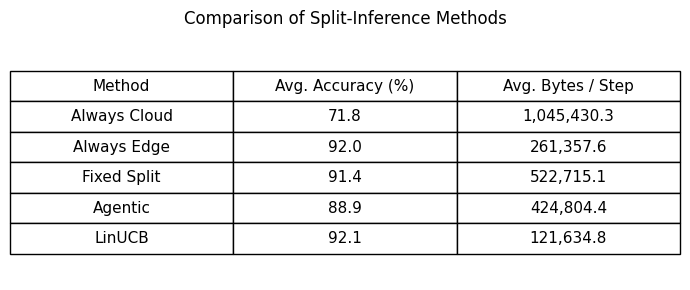


Final Comparison
-------------------------------------------------------
Always Cloud   Accuracy: 71.8%   Bytes/step: 1,045,430.3
Always Edge    Accuracy: 92.0%   Bytes/step: 261,357.6
Fixed Split    Accuracy: 91.4%   Bytes/step: 522,715.1
Agentic        Accuracy: 88.9%   Bytes/step: 424,804.4
LinUCB         Accuracy: 92.1%   Bytes/step: 121,634.8


In [32]:
# 15. Final Comparison Table

names = [
    "always_cloud",
    "always_edge",
    "fixed_split",
    "agentic",
    "agentic_ucb"
]

labels = {
    "always_cloud": "Always Cloud",
    "always_edge": "Always Edge",
    "fixed_split": "Fixed Split",
    "agentic": "Agentic",
    "agentic_ucb": "LinUCB"
}

rows = []

for name in names:
    acc = np.mean(results[name]["acc"]) * 100
    bytes_sent = np.mean(results[name]["bytes"])

    rows.append([
        labels[name],
        f"{acc:.1f}",
        f"{bytes_sent:,.1f}"
    ])

fig, ax = plt.subplots(figsize=(7, 3))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=[
        "Method",
        "Avg. Accuracy (%)",
        "Avg. Bytes / Step"
    ],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

plt.title(
    "Comparison of Split-Inference Methods",
    pad=15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        out_dir,
        "final_comparison_table.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFinal Comparison")
print("-" * 55)

for name in names:
    acc = np.mean(results[name]["acc"]) * 100
    bytes_sent = np.mean(results[name]["bytes"])

    print(
        f"{labels[name]:<15}"
        f"Accuracy: {acc:.1f}%   "
        f"Bytes/step: {bytes_sent:,.1f}"
    )

In [37]:
# 15. LinUCB Learned Policy

print("LinUCB policy")

snr_values = np.linspace(0, 25, 11)

for snr in snr_values:

    _, (cut, bits) = agent_ucb.choose(
        snr,
        training=False
    )

    print(
        f"SNR {snr:.1f} dB: "
        f"cut={cut}, bits={bits}"
    )

LinUCB policy
SNR 0.0 dB: cut=3, bits=4
SNR 2.5 dB: cut=3, bits=4
SNR 5.0 dB: cut=3, bits=4
SNR 7.5 dB: cut=3, bits=4
SNR 10.0 dB: cut=3, bits=4
SNR 12.5 dB: cut=3, bits=4
SNR 15.0 dB: cut=3, bits=4
SNR 17.5 dB: cut=3, bits=4
SNR 20.0 dB: cut=3, bits=4
SNR 22.5 dB: cut=3, bits=4
SNR 25.0 dB: cut=3, bits=2
